Training samples: 18  Testing samples: 12

Comparison of models (polynomial degree = 12 ):
              Model  Train MSE  Test MSE  Train R2  Test R2   Max |coef|  Zero coef
  Linear Regression     0.0062    6.3601    0.9905 -19.5778 20160639.612          0
Ridge (alpha=0.001)     0.0232    0.0558    0.9641   0.8195        5.975          0
Lasso (alpha=0.001)     0.0261    0.0647    0.9597   0.7907        5.197          8

Ridge: effect of alpha
alpha      Train MSE   Test MSE
0.0001     0.0226      0.0527
0.001      0.0232      0.0558
0.01       0.0298      0.0741
0.1        0.0626      0.1111
1          0.1222      0.1698
10         0.1848      0.1506
100        0.3905      0.1759


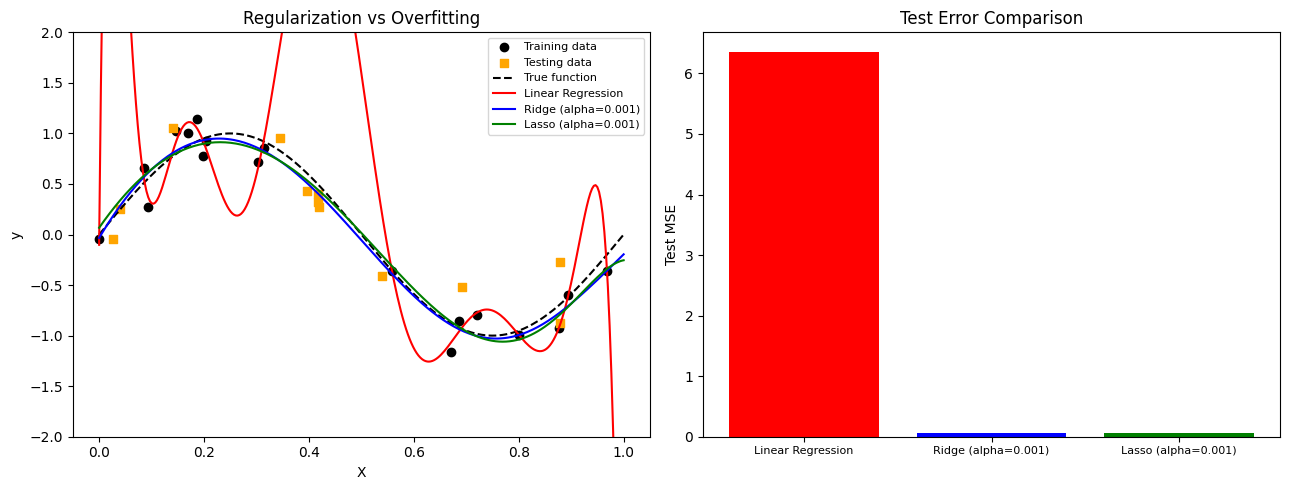

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(1)
X = np.sort(np.random.rand(30, 1), axis=0)
y = np.sin(2 * np.pi * X).ravel() + np.random.normal(0, 0.25, 30)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.40, random_state=3)
print("Training samples:", len(X_train), " Testing samples:", len(X_test))

degree = 12
poly = PolynomialFeatures(degree)
X_train_p = poly.fit_transform(X_train)
X_test_p = poly.transform(X_test)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train_p)
X_test_s = scaler.transform(X_test_p)

lin = LinearRegression().fit(X_train_s, y_train)
ridge = Ridge(alpha=0.001).fit(X_train_s, y_train)
lasso = Lasso(alpha=0.001, max_iter=100000).fit(X_train_s, y_train)

models = [('Linear Regression', lin), ('Ridge (alpha=0.001)', ridge),
          ('Lasso (alpha=0.001)', lasso)]

rows = []
for name, m in models:
    tr = m.predict(X_train_s)
    te = m.predict(X_test_s)
    coef = m.coef_
    rows.append([name,
                 round(mean_squared_error(y_train, tr), 4),
                 round(mean_squared_error(y_test, te), 4),
                 round(r2_score(y_train, tr), 4),
                 round(r2_score(y_test, te), 4),
                 round(np.abs(coef).max(), 3),
                 int(np.sum(np.abs(coef[1:]) < 1e-6))])

table = pd.DataFrame(rows, columns=['Model', 'Train MSE', 'Test MSE',
                                    'Train R2', 'Test R2',
                                    'Max |coef|', 'Zero coef'])
print("\nComparison of models (polynomial degree =", degree, "):")
print(table.to_string(index=False))

alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
print("\nRidge: effect of alpha")
print("alpha      Train MSE   Test MSE")
test_err = []
for a in alphas:
    m = Ridge(alpha=a).fit(X_train_s, y_train)
    tr = mean_squared_error(y_train, m.predict(X_train_s))
    te = mean_squared_error(y_test, m.predict(X_test_s))
    test_err.append(te)
    print(f"{a:<10} {tr:.4f}      {te:.4f}")

X_line = np.linspace(0, 1, 300).reshape(-1, 1)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
ax[0].scatter(X_train, y_train, color='black', label='Training data')
ax[0].scatter(X_test, y_test, color='orange', marker='s',
              label='Testing data')
ax[0].plot(X_line, np.sin(2 * np.pi * X_line), 'k--', label='True function')
X_line_s = scaler.transform(poly.transform(X_line))
for (name, m), c in zip(models, ['red', 'blue', 'green']):
    ax[0].plot(X_line, m.predict(X_line_s), color=c, label=name)
ax[0].set_ylim(-2, 2)
ax[0].set_xlabel("X")
ax[0].set_ylabel("y")
ax[0].set_title("Regularization vs Overfitting")
ax[0].legend(fontsize=8)

names = [name for name, m in models]
ax[1].bar(names, table['Test MSE'], color=['red', 'blue', 'green'])
ax[1].set_ylabel("Test MSE")
ax[1].set_title("Test Error Comparison")
ax[1].tick_params(axis='x', labelsize=8)
plt.tight_layout()
plt.show()
